In [30]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

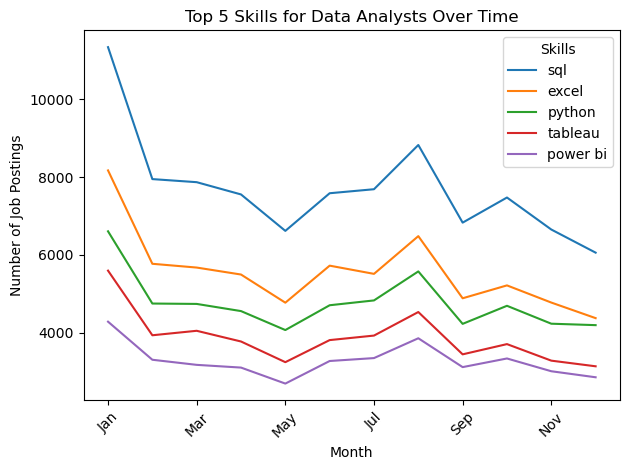

In [32]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()
df_da["job_posted_month_no"] = df_da["job_posted_date"].dt.month

df_da_explode = df_da.explode('job_skills')
df_da_pivot = df_da_explode.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc='size', fill_value=0)

df_da_pivot.loc["Total"] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending=False).index]
# Sort the values in descending order based on the "Total" row
#df_da_pivot_s2 = df_da_pivot.sort_values(by="Total", ascending=False, axis=1)
df_da_pivot = df_da_pivot.drop("Total")

# Need to use month names instead of month numbers for better readability
df_da_pivot = df_da_pivot.reset_index()
df_da_pivot['job_posted_month'] = df_da_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_pivot = df_da_pivot.set_index("job_posted_month")
df_da_pivot = df_da_pivot.drop(columns=["job_posted_month_no"])

# Get the top 5 skills using iloc
df_da_pivot.iloc[:, :5].plot(kind='line')
plt.title('Top 5 Skills for Data Analysts Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.legend(title='Skills')
plt.tight_layout()
plt.show()


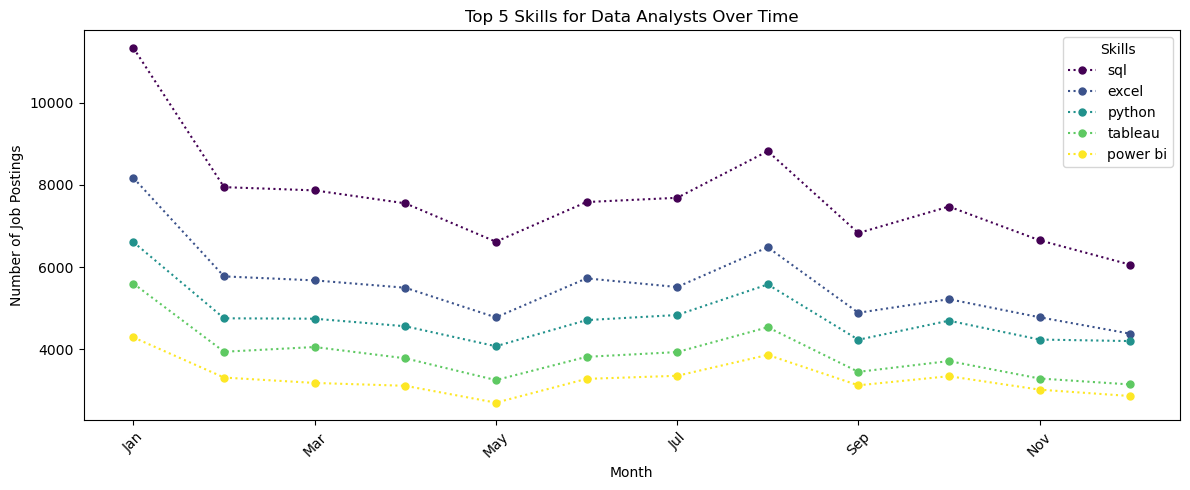

In [41]:
df_da_pivot.iloc[:, :5].plot(
    kind='line',
    linestyle=':',
    colormap='viridis',
    markersize=5,
    marker='o',
    figsize=(12, 5)
    )
plt.title('Top 5 Skills for Data Analysts Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.legend(title='Skills')
plt.tight_layout()
plt.show()

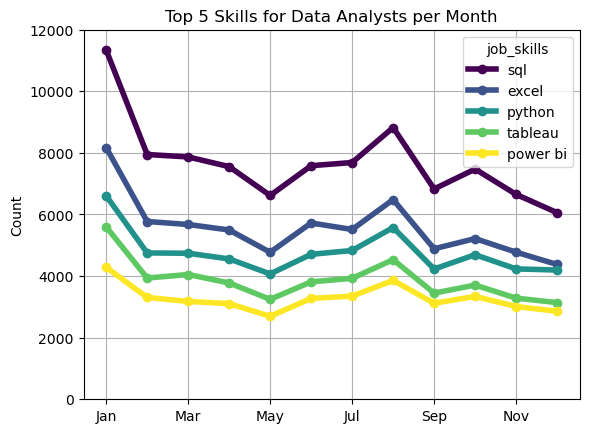

In [42]:
df_da_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle='-', # options: '-', '--', '-.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis' 
    markersize=6,
    marker='o', # options: 'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...
    # figsize=(10, 5)
)

plt.grid(True)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylim(0, 12000)
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [43]:
df_exploded = df.explode('job_skills').copy()

skill_stats = df_exploded.groupby('job_skills').agg(
    skills_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skills_count', ascending=False).head(20)

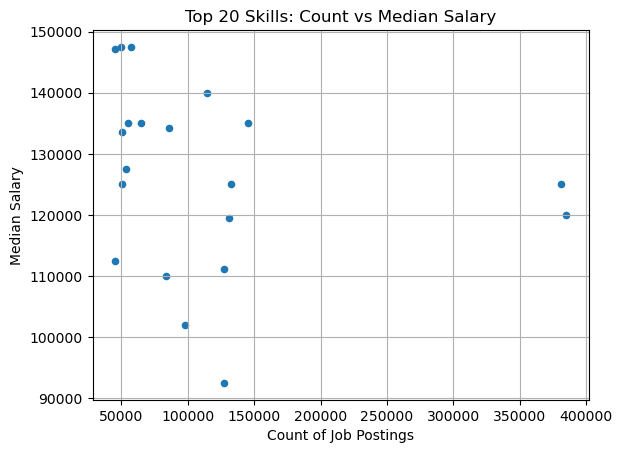

In [44]:
skill_stats.plot(
    kind='scatter',
    x='skills_count',
    y='median_salary'
)
plt.title('Top 20 Skills: Count vs Median Salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary')
plt.grid(True)
plt.show()

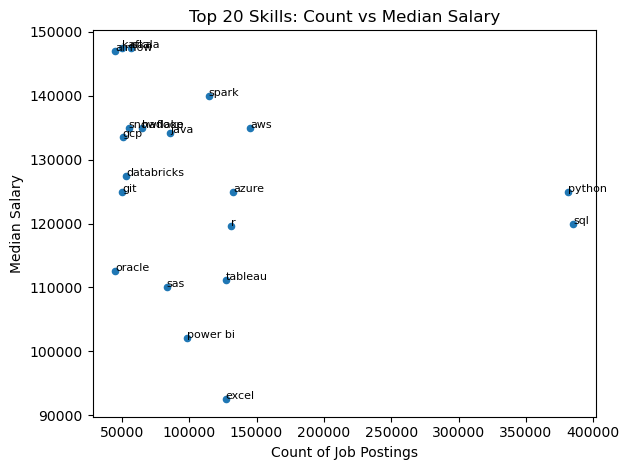

In [50]:
skill_stats.plot(kind='scatter', x='skills_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skills_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt, fontsize=8)
plt.title('Top 20 Skills: Count vs Median Salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary')
plt.tight_layout()
plt.show()

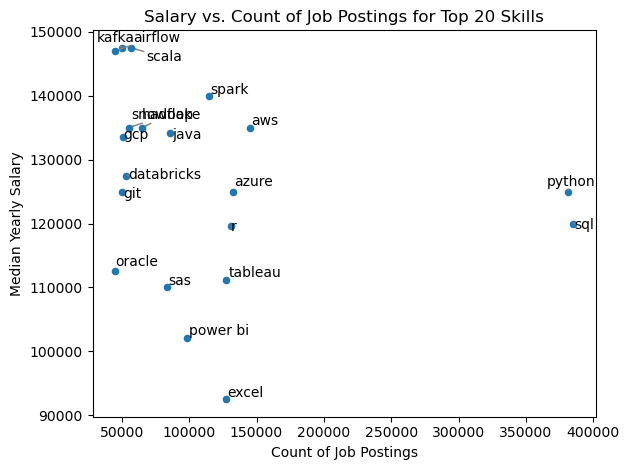

In [53]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skills_count', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skills_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top 20 Skills')

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

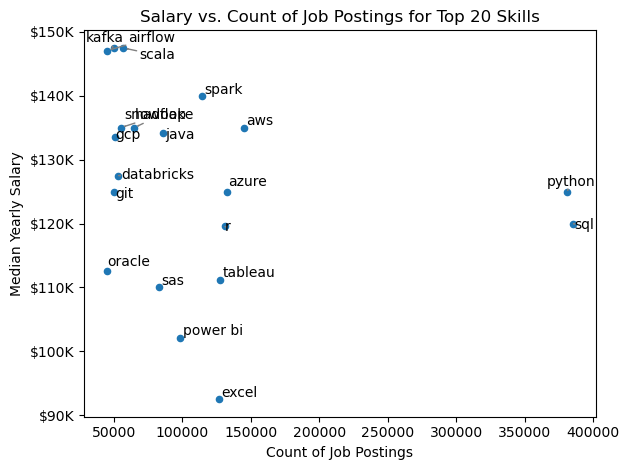

In [54]:
skill_stats.plot(kind='scatter', x='skills_count', y='median_salary')
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skills_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top 20 Skills')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

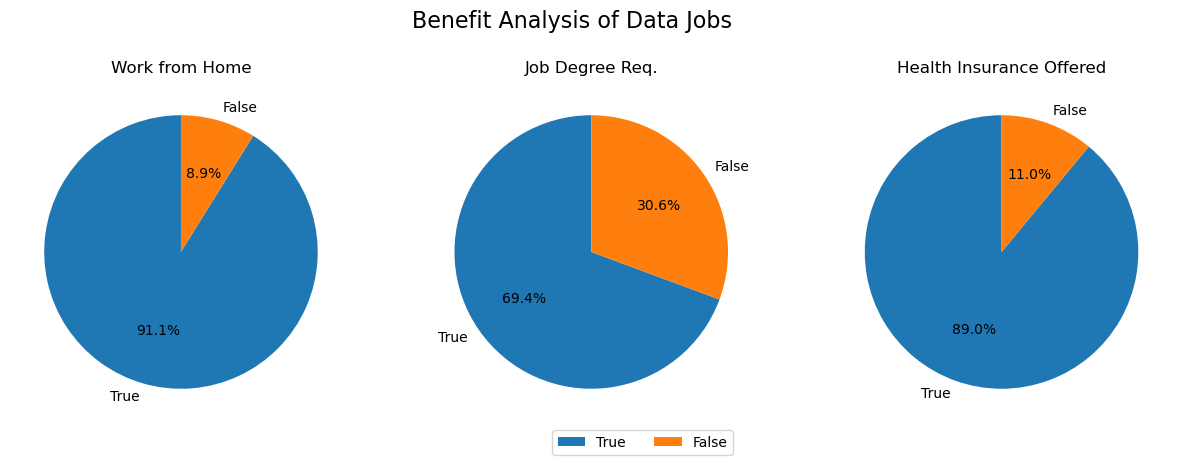

In [55]:
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['True', 'False'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.legend(loc='upper center', bbox_to_anchor=(-0.55, 0), ncol=2)
plt.show()

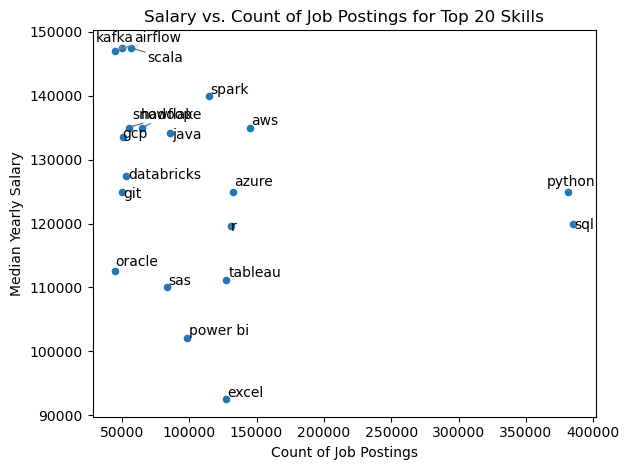

In [56]:
skill_stats.plot(kind='scatter', x='skills_count', y='median_salary')
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skills_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
     
# Set axis labels, title, and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top 20 Skills')

# Get current axes
ax = plt.gca()

# Adjust layout and display plot 
plt.tight_layout()
plt.show()